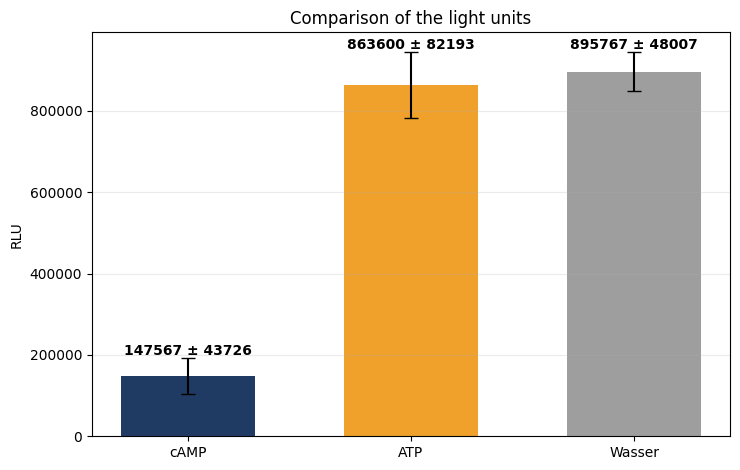

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Pfad/Sheet anpassen
# -----------------------------
excel_path = "group 3 and 4 PCA.xlsx"   # <-- deinen Dateinamen einsetzen
sheet_name = 0

raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None, engine="openpyxl")

# Zeilen aus deiner Tabelle (0-basiert!)
labels = raw.iloc[7, 1:]   # Zeile 8 in Excel → Index 7
values = raw.iloc[11, 1:]  # Zeile 12 in Excel → Index 11

# In DataFrame umwandeln
df = pd.DataFrame({"condition": labels, "RLU": values})
df = df.dropna(subset=["condition", "RLU"])

# Nur die relevanten Bedingungen behalten
keep = {"Wasser", "ATP", "cAMP"}
df = df[df["condition"].astype(str).str.strip().isin(keep)].copy()

# Zahlen erzwingen
df["RLU"] = pd.to_numeric(df["RLU"], errors="coerce")

# -----------------------------
# Mittelwert & Standardabweichung berechnen
# -----------------------------
order = ["cAMP", "ATP", "Wasser"]  # Reihenfolge wie im Diagramm
stats = (
    df.groupby("condition")["RLU"]
      .agg(["mean", "std", "count"])
      .reindex(order)
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7.5, 4.8))

colors = {
    "cAMP":  "#1f3b64",   # dunkelblau
    "ATP":   "#f0a12b",   # orange
    "Wasser":"#9e9e9e"    # grau
}
bar_colors = [colors[c] for c in stats.index]

x = np.arange(len(stats))
means = stats["mean"].values
errs = stats["std"].values
ns = stats["count"].values

bars = plt.bar(x, means, yerr=errs, capsize=5, width=0.6, color=bar_colors)

# Beschriftung über jedem Balken – etwas tiefer gesetzt
for xi, m, s in zip(x, means, errs):
    plt.text(
        xi,
        m + s * 1,          # 👈 statt +s+30000 — jetzt dynamisch 30 % über dem Balken
        f"{m:.0f} ± {s:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",        # heller Text sieht oft schöner aus auf dunklem Hintergrund
        fontweight="semibold"
    )

# Achsen & Layout
plt.xticks(x, stats.index)
plt.ylabel("RLU")
plt.title("Comparison of the light units")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [17]:
# ===============================
# Überprüfen der eingelesenen und berechneten Daten
# ===============================

print("📊 Rohdaten:")
print(df)

print("\n📈 Gruppierte Statistik (Mittelwert, SD, n):")
print(stats)

# Optional: nur zur Kontrolle
for cond, group in df.groupby("condition"):
    print(f"\n🔹 {cond} ({len(group)} Replikate):")
    print(group["RLU"].values)

📊 Rohdaten:
  condition     RLU
1    Wasser  847300
2    Wasser  896700
3    Wasser  943300
4       ATP  774100
5       ATP  935700
6       ATP  881000
7      cAMP  196200
8      cAMP  135000
9      cAMP  111500

📈 Gruppierte Statistik (Mittelwert, SD, n):
                    mean           std  count
condition                                    
cAMP       147566.666667  43726.002943      3
ATP        863600.000000  82193.126233      3
Wasser     895766.666667  48006.805073      3

🔹 ATP (3 Replikate):
[774100 935700 881000]

🔹 Wasser (3 Replikate):
[847300 896700 943300]

🔹 cAMP (3 Replikate):
[196200 135000 111500]
